In [1]:
# ============================================================
# Install required packages
# ============================================================
!pip -q install xlrd openpyxl xgboost imbalanced-learn joblib

In [2]:
# ============================================================
# Import libraries and set project configuration
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
FAST_MODE = True   # Keep True for Colab. Change to False only if you have enough time.

OUTPUT_DIR = "/content/credit_default_outputs"
FIG_DIR = f"{OUTPUT_DIR}/figures"
TABLE_DIR = f"{OUTPUT_DIR}/tables"
MODEL_DIR = f"{OUTPUT_DIR}/models"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Setup complete.")
print("XGBoost available:", HAS_XGB)


Setup complete.
XGBoost available: True


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ============================================================
# Upload and load dataset
# ============================================================
# Upload the file: default of credit card clients.xls
# If the file is already in /content, this cell will use it directly.

DATA_PATH = "/content/drive/MyDrive/Herts/CCD PROJECT/default of credit card clients.xls"

if not os.path.exists(DATA_PATH):
    print("Upload your dataset file: /content/drive/MyDrive/Herts/CCD PROJECT/default of credit card clients.xls")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

print("Using dataset:", DATA_PATH)

# The UCI Excel file has the real column names on row 2, so header=1 is required.
df = pd.read_excel(DATA_PATH, header=1)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# Rename target column
if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default"})

print("Shape:", df.shape)
display(df.head())
display(df.info())

Using dataset: /content/drive/MyDrive/Herts/CCD PROJECT/default of credit card clients.xls
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

None

In [9]:
# ============================================================
# Initial data quality checks
# ============================================================
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["default"].value_counts())
display(df["default"].value_counts(normalize=True).rename("proportion"))

# Remove ID column because it is only an identifier and has no predictive meaning
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Basic category cleaning based on UCI dataset coding:
# EDUCATION: 1=graduate school, 2=university, 3=high school, 4=others, 5/6/0=unknown/other
# MARRIAGE: 1=married, 2=single, 3=others, 0=unknown/other
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("Cleaned EDUCATION values:", sorted(df["EDUCATION"].unique()))
print("Cleaned MARRIAGE values:", sorted(df["MARRIAGE"].unique()))

Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

Missing values:


,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0



Duplicate rows: 0

Target distribution:


,count
default,
0,23364
1,6636


,proportion
default,
0,0.7788
1,0.2212


Cleaned EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Cleaned MARRIAGE values: [np.int64(1), np.int64(2), np.int64(3)]


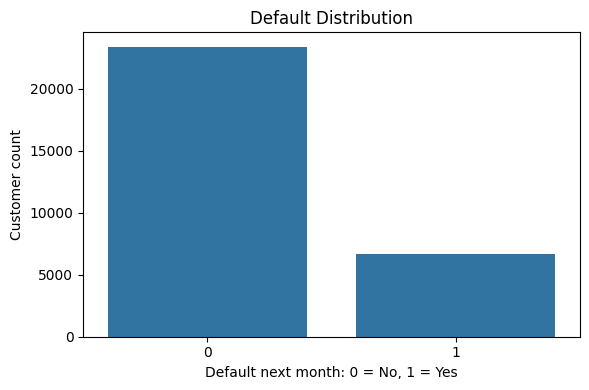

In [10]:
# ============================================================
# Default distribution
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="default")

plt.title("Default Distribution")
plt.xlabel("Default next month: 0 = No, 1 = Yes")
plt.ylabel("Customer count")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_default_distribution.png", dpi=300)

plt.show()

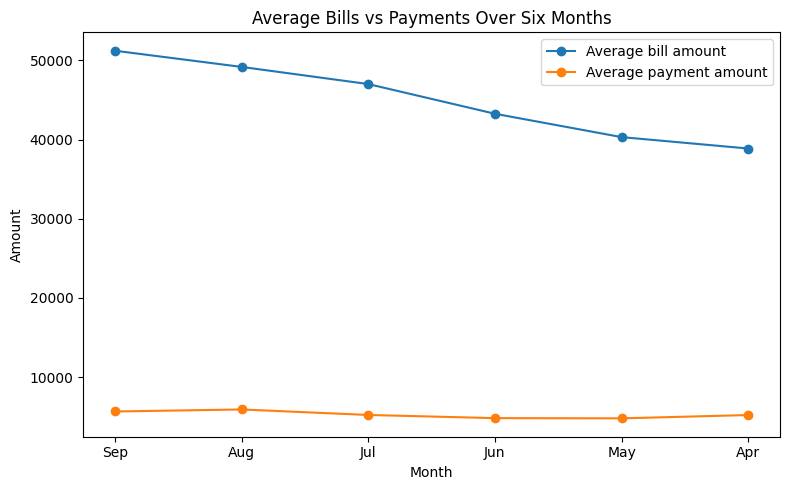

In [11]:
# ============================================================
# Bills vs Payments over six months
# ============================================================

bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

months = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]

avg_bills = df[bill_cols].mean().values
avg_payments = df[pay_amt_cols].mean().values

plt.figure(figsize=(8, 5))

plt.plot(months, avg_bills,
         marker="o",
         label="Average bill amount")

plt.plot(months, avg_payments,
         marker="o",
         label="Average payment amount")

plt.title("Average Bills vs Payments Over Six Months")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_bills_vs_payments.png", dpi=300)

plt.show()

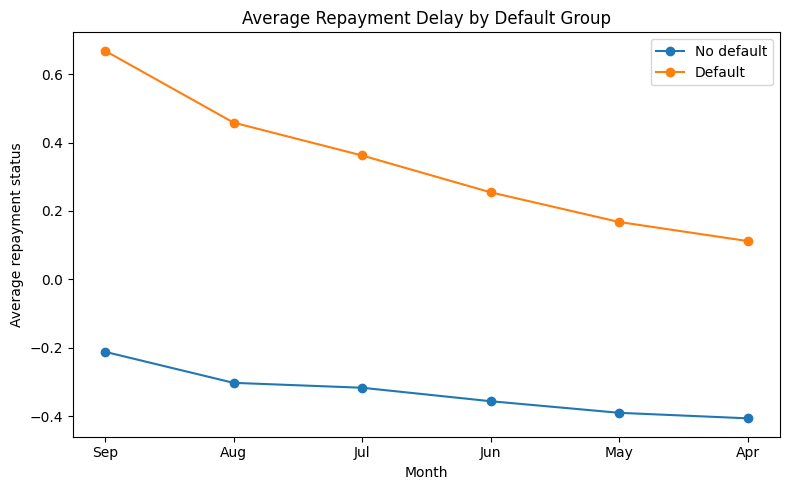

In [12]:
# ============================================================
# Repayment delay trend by default group
# ============================================================

pay_status_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

delay_by_default = (
    df.groupby("default")[pay_status_cols]
      .mean()
      .T
)

delay_by_default.index = [
    "Sep", "Aug", "Jul",
    "Jun", "May", "Apr"
]

plt.figure(figsize=(8, 5))

plt.plot(
    delay_by_default.index,
    delay_by_default[0],
    marker="o",
    label="No default"
)

plt.plot(
    delay_by_default.index,
    delay_by_default[1],
    marker="o",
    label="Default"
)

plt.title("Average Repayment Delay by Default Group")
plt.xlabel("Month")
plt.ylabel("Average repayment status")

plt.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_repayment_delay_by_default.png", dpi=300)

plt.show()

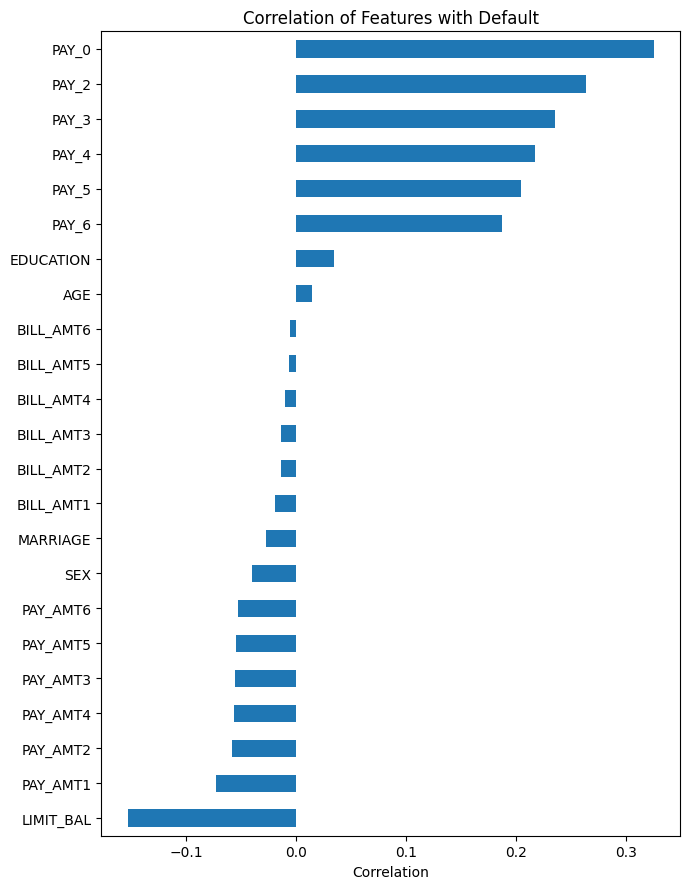

,default
default,1.000000
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.033842
AGE,0.013890
BILL_AMT6,-0.005372


In [13]:
# ============================================================
# Correlation with target
# ============================================================

corr_with_target = (
    df.corr(numeric_only=True)["default"]
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 9))

corr_with_target.drop("default") \
    .sort_values() \
    .plot(kind="barh")

plt.title("Correlation of Features with Default")
plt.xlabel("Correlation")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_target_correlation.png", dpi=300)

plt.show()

display(corr_with_target.head(15))

In [14]:
# ============================================================
# Feature engineering
# ============================================================
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create stronger behaviour-based credit risk features."""
    X = data.copy()

    pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
    bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
    pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

    # Repayment behaviour features
    X["avg_pay_delay"] = X[pay_status_cols].mean(axis=1)
    X["max_pay_delay"] = X[pay_status_cols].max(axis=1)
    X["min_pay_delay"] = X[pay_status_cols].min(axis=1)
    X["months_late"] = (X[pay_status_cols] > 0).sum(axis=1)
    X["months_2plus_late"] = (X[pay_status_cols] >= 2).sum(axis=1)
    X["recent_delay"] = X["PAY_0"]
    X["delay_trend_recent_minus_old"] = X["PAY_0"] - X["PAY_6"]

    # Bill behaviour features
    X["avg_bill_amt"] = X[bill_cols].mean(axis=1)
    X["total_bill_amt"] = X[bill_cols].sum(axis=1)
    X["max_bill_amt"] = X[bill_cols].max(axis=1)
    X["bill_amt_std"] = X[bill_cols].std(axis=1)
    X["bill_trend_recent_minus_old"] = X["BILL_AMT1"] - X["BILL_AMT6"]

    # Payment behaviour features
    X["avg_pay_amt"] = X[pay_amt_cols].mean(axis=1)
    X["total_pay_amt"] = X[pay_amt_cols].sum(axis=1)
    X["max_pay_amt"] = X[pay_amt_cols].max(axis=1)
    X["pay_amt_std"] = X[pay_amt_cols].std(axis=1)
    X["pay_trend_recent_minus_old"] = X["PAY_AMT1"] - X["PAY_AMT6"]

    # Utilisation features
    X["recent_utilisation"] = X["BILL_AMT1"] / (X["LIMIT_BAL"] + 1)
    X["avg_utilisation"] = X["avg_bill_amt"] / (X["LIMIT_BAL"] + 1)
    X["max_utilisation"] = X["max_bill_amt"] / (X["LIMIT_BAL"] + 1)

    # Payment-to-bill ratios. Use absolute bill amount to avoid division issues with negative/credit balances.
    ratio_values = []
    for bill_col, pay_col in zip(bill_cols, pay_amt_cols):
        ratio = X[pay_col] / (X[bill_col].abs() + 1)
        ratio_values.append(ratio.clip(lower=0, upper=5))
    ratio_df = pd.concat(ratio_values, axis=1)
    X["avg_payment_to_bill_ratio"] = ratio_df.mean(axis=1)
    X["min_payment_to_bill_ratio"] = ratio_df.min(axis=1)

    # Risk flags
    X["zero_payment_months"] = (X[pay_amt_cols] == 0).sum(axis=1)
    X["high_utilisation_flag"] = (X["recent_utilisation"] > 0.8).astype(int)
    X["any_2plus_delay_flag"] = (X["months_2plus_late"] > 0).astype(int)

    # Age bands for fairness / subgroup analysis
    X["AGE_BAND"] = pd.cut(
        X["AGE"],
        bins=[0, 25, 35, 45, 55, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "56+"]
    ).astype(str)

    # Credit limit bands
    X["LIMIT_BAND"] = pd.qcut(
        X["LIMIT_BAL"],
        q=4,
        labels=["low_limit", "mid_low_limit", "mid_high_limit", "high_limit"],
        duplicates="drop"
    ).astype(str)

    return X

y = df["default"].astype(int)
X_raw = df.drop(columns=["default"])
X = engineer_features(X_raw)

print("Original feature count:", X_raw.shape[1])
print("New feature count:", X.shape[1])
display(X.head())

Original feature count: 23
New feature count: 50


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,recent_utilisation,avg_utilisation,max_utilisation,avg_payment_to_bill_ratio,min_payment_to_bill_ratio,zero_payment_months,high_utilisation_flag,any_2plus_delay_flag,AGE_BAND,LIMIT_BAND
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.195640,0.064197,0.195640,0.037007,0.000000,5,0,1,<=25,low_limit
1,120000,2,2,2,26,-1,2,0,0,0,...,0.022350,0.023718,0.028791,0.311790,0.000000,2,0,1,26-35,mid_low_limit
2,90000,2,2,2,34,0,0,0,0,0,...,0.324874,0.188244,0.324874,0.115134,0.051915,0,0,0,26-35,mid_low_limit
3,50000,2,2,1,37,0,0,0,0,0,...,0.939781,0.771098,0.985800,0.036395,0.024345,0,1,0,36-45,low_limit
4,50000,1,2,1,57,-1,0,-1,0,0,...,0.172337,0.364456,0.716686,1.002063,0.035490,0,0,0,56+,low_limit


In [15]:
# ============================================================
# Train / validation / test split
# ============================================================
# Train = model fitting
# Validation = threshold tuning and model selection
# Test = final unbiased evaluation

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 0.25 of 80% = 20%, so split is 60/20/20
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True).to_dict())
print("Validation:", X_val.shape, y_val.value_counts(normalize=True).to_dict())
print("Test:", X_test.shape, y_test.value_counts(normalize=True).to_dict())

Train: (18000, 50) {0: 0.7787777777777778, 1: 0.2212222222222222}
Validation: (6000, 50) {0: 0.7788333333333334, 1: 0.22116666666666668}
Test: (6000, 50) {0: 0.7788333333333334, 1: 0.22116666666666668}


In [16]:
# ============================================================
# Preprocessing pipelines
# ============================================================
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_BAND", "LIMIT_BAND"]
numeric_features = [c for c in X.columns if c not in categorical_features]

numeric_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

preprocess_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_unscaled, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features: 45
Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_BAND', 'LIMIT_BAND']


In [18]:
# ============================================================
# Evaluation helper functions
# ============================================================
def get_proba(model, X_data):
    """Return probability of default class 1."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        return (scores - scores.min()) / (scores.max() - scores.min())
    raise ValueError("Model does not support probability prediction.")


def tune_threshold(y_true, y_proba, beta=2):
    """Tune threshold to maximise F-beta score on validation data."""
    thresholds = np.arange(0.05, 0.96, 0.01)
    rows = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "f2": fbeta_score(y_true, pred, beta=beta, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    best = threshold_df.sort_values("f2", ascending=False).iloc[0]
    return float(best["threshold"]), threshold_df


def evaluate_predictions(y_true, y_proba, threshold=0.50):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def print_report(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    print("\n" + "="*70)
    print(name)
    print("="*70)
    print("Threshold:", round(threshold, 3))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))


def get_feature_names_from_pipeline(pipe):
    preprocessor = pipe.named_steps["preprocess"]
    names = []

    # numeric names
    names.extend(numeric_features)

    # categorical one-hot names
    cat_transformer = preprocessor.named_transformers_["cat"]
    ohe = cat_transformer.named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    names.extend(cat_names)

    return np.array(names)

In [20]:
# ============================================================
# Models
# 1. Balanced Logistic Regression
# 2. XGBoost Weighted
# ============================================================

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight for XGBoost:", scale_pos_weight)

models = {}

# Model 1: Balanced Logistic Regression
models["Logistic Regression Balanced"] = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

# Model 2: XGBoost Weighted
if HAS_XGB:
    models["XGBoost Weighted"] = Pipeline(steps=[
        ("preprocess", preprocess_unscaled),
        ("clf", XGBClassifier(
            n_estimators=400,
            learning_rate=0.04,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
else:
    raise ImportError("XGBoost is not installed. Run the package installation cell first.")

validation_rows = []
fitted_models = {}
threshold_tables = {}

for name, model in models.items():
    print(f"Training: {name}")
    model.fit(X_train, y_train)
    fitted_models[name] = model

    val_proba = get_proba(model, X_val)
    best_threshold, threshold_df = tune_threshold(y_val, val_proba, beta=2)
    threshold_tables[name] = threshold_df

    metrics_050 = evaluate_predictions(y_val, val_proba, threshold=0.50)
    metrics_tuned = evaluate_predictions(y_val, val_proba, threshold=best_threshold)

    row = {
        "model": name,
        "best_threshold": best_threshold,
        "valid_roc_auc": metrics_tuned["roc_auc"],
        "valid_pr_auc": metrics_tuned["pr_auc"],
        "valid_f1_tuned": metrics_tuned["f1"],
        "valid_f2_tuned": metrics_tuned["f2"],
        "valid_recall_tuned": metrics_tuned["recall"],
        "valid_precision_tuned": metrics_tuned["precision"],
        "valid_accuracy_tuned": metrics_tuned["accuracy"],
        "valid_f1_at_050": metrics_050["f1"],
        "valid_recall_at_050": metrics_050["recall"],
        "valid_precision_at_050": metrics_050["precision"],
    }

    validation_rows.append(row)

validation_summary = pd.DataFrame(validation_rows).sort_values(
    by=["valid_pr_auc", "valid_f2_tuned"],
    ascending=False
)

display(validation_summary)
validation_summary.to_csv(f"{TABLE_DIR}/validation_model_comparison.csv", index=False)

scale_pos_weight for XGBoost: 3.5203415369161224
Training: Logistic Regression Balanced
Training: XGBoost Weighted


,model,best_threshold,valid_roc_auc,valid_pr_auc,valid_f1_tuned,valid_f2_tuned,valid_recall_tuned,valid_precision_tuned,valid_accuracy_tuned,valid_f1_at_050,valid_recall_at_050,valid_precision_at_050
1,XGBoost Weighted,0.33,0.787603,0.562114,0.482388,0.650110,0.846270,0.337339,0.598333,0.544868,0.636021,0.476567
0,Logistic Regression Balanced,0.34,0.771356,0.523252,0.470588,0.633264,0.822909,0.329511,0.590500,0.520971,0.622457,0.447939


In [22]:
# ============================================================
# Hyperparameter tuning for XGBoost only
# Model 3: Tuned XGBoost
# ============================================================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess_unscaled),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_param_dist = {
    "clf__n_estimators": [250, 400, 600, 800],
    "clf__learning_rate": [0.02, 0.04, 0.06, 0.1],
    "clf__max_depth": [3, 4, 5, 6],
    "clf__min_child_weight": [1, 3, 5, 8],
    "clf__subsample": [0.75, 0.85, 1.0],
    "clf__colsample_bytree": [0.75, 0.85, 1.0],
    "clf__reg_lambda": [1, 2, 5, 10],
    "clf__reg_alpha": [0, 0.1, 0.5, 1]
}

xgb_n_iter = 8 if FAST_MODE else 25

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=xgb_n_iter,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)

print("Best XGBoost params:")
print(xgb_search.best_params_)

print("Best XGBoost CV PR-AUC:")
print(xgb_search.best_score_)

fitted_models["Tuned XGBoost"] = xgb_search.best_estimator_

xgb_val_proba = get_proba(xgb_search.best_estimator_, X_val)
xgb_best_threshold, xgb_threshold_df = tune_threshold(y_val, xgb_val_proba, beta=2)
threshold_tables["Tuned XGBoost"] = xgb_threshold_df

# Add Tuned XGBoost to validation summary
metrics_050 = evaluate_predictions(y_val, xgb_val_proba, threshold=0.50)
metrics_tuned = evaluate_predictions(y_val, xgb_val_proba, threshold=xgb_best_threshold)

tuned_xgb_row = {
    "model": "Tuned XGBoost",
    "best_threshold": xgb_best_threshold,
    "valid_roc_auc": metrics_tuned["roc_auc"],
    "valid_pr_auc": metrics_tuned["pr_auc"],
    "valid_f1_tuned": metrics_tuned["f1"],
    "valid_f2_tuned": metrics_tuned["f2"],
    "valid_recall_tuned": metrics_tuned["recall"],
    "valid_precision_tuned": metrics_tuned["precision"],
    "valid_accuracy_tuned": metrics_tuned["accuracy"],
    "valid_f1_at_050": metrics_050["f1"],
    "valid_recall_at_050": metrics_050["recall"],
    "valid_precision_at_050": metrics_050["precision"],
}

validation_summary = pd.concat(
    [validation_summary, pd.DataFrame([tuned_xgb_row])],
    ignore_index=True
).sort_values(by=["valid_pr_auc", "valid_f2_tuned"], ascending=False)

display(validation_summary)
validation_summary.to_csv(f"{TABLE_DIR}/validation_model_comparison.csv", index=False)

print("XGBoost tuning complete.")

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost params:
{'clf__subsample': 1.0, 'clf__reg_lambda': 5, 'clf__reg_alpha': 1, 'clf__n_estimators': 400, 'clf__min_child_weight': 1, 'clf__max_depth': 4, 'clf__learning_rate': 0.02, 'clf__colsample_bytree': 0.75}
Best XGBoost CV PR-AUC:
0.5632231620033763


,model,best_threshold,valid_roc_auc,valid_pr_auc,valid_f1_tuned,valid_f2_tuned,valid_recall_tuned,valid_precision_tuned,valid_accuracy_tuned,valid_f1_at_050,valid_recall_at_050,valid_precision_at_050
0,XGBoost Weighted,0.33,0.787603,0.562114,0.482388,0.650110,0.846270,0.337339,0.598333,0.544868,0.636021,0.476567
2,Tuned XGBoost,0.36,0.785904,0.558760,0.486667,0.645561,0.825170,0.345099,0.615000,0.539275,0.633760,0.469308
1,Logistic Regression Balanced,0.34,0.771356,0.523252,0.470588,0.633264,0.822909,0.329511,0.590500,0.520971,0.622457,0.447939


XGBoost tuning complete.


In [23]:
# ============================================================
# Final test-set evaluation for 3 models
# ============================================================

final_rows = []

for name, model in fitted_models.items():
    val_proba = get_proba(model, X_val)
    best_threshold, _ = tune_threshold(y_val, val_proba, beta=2)

    test_proba = get_proba(model, X_test)
    metrics = evaluate_predictions(y_test, test_proba, threshold=best_threshold)
    metrics["model"] = name
    final_rows.append(metrics)

test_summary = pd.DataFrame(final_rows)

cols = [
    "model", "threshold", "accuracy", "balanced_accuracy",
    "precision", "recall", "specificity", "f1", "f2",
    "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"
]

test_summary = test_summary[cols].sort_values(
    by=["pr_auc", "f2"],
    ascending=False
)

display(test_summary)
test_summary.to_csv(f"{TABLE_DIR}/final_test_model_comparison.csv", index=False)

# Select best model using validation PR-AUC and F2-score, not test results
best_model_name = validation_summary.sort_values(
    by=["valid_pr_auc", "valid_f2_tuned"],
    ascending=False
).iloc[0]["model"]

best_model = fitted_models[best_model_name]

best_val_proba = get_proba(best_model, X_val)
best_threshold, best_threshold_df = tune_threshold(y_val, best_val_proba, beta=2)

best_test_proba = get_proba(best_model, X_test)

print("Best model selected from validation:", best_model_name)
print("Best threshold:", best_threshold)

print_report(best_model_name, y_test, best_test_proba, best_threshold)

joblib.dump(best_model, f"{MODEL_DIR}/best_model.pkl")

with open(f"{MODEL_DIR}/best_model_threshold.txt", "w") as f:
    f.write(str(best_threshold))

,model,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,f2,roc_auc,pr_auc,tn,fp,fn,tp
2,Tuned XGBoost,0.36,0.612333,0.687183,0.342875,0.821402,0.552964,0.483799,0.642159,0.783025,0.562486,2584,2089,237,1090
1,XGBoost Weighted,0.33,0.594000,0.677571,0.332224,0.827430,0.527712,0.474093,0.637409,0.780719,0.562109,2466,2207,229,1098
0,Logistic Regression Balanced,0.34,0.582000,0.662583,0.322299,0.807084,0.518083,0.460645,0.620438,0.761271,0.523305,2421,2252,256,1071


Best model selected from validation: XGBoost Weighted
Best threshold: 0.33

XGBoost Weighted
Threshold: 0.33
Confusion matrix:
[[2466 2207]
 [ 229 1098]]

Classification report:
              precision    recall  f1-score   support

           0     0.9150    0.5277    0.6694      4673
           1     0.3322    0.8274    0.4741      1327

    accuracy                         0.5940      6000
   macro avg     0.6236    0.6776    0.5717      6000
weighted avg     0.7861    0.5940    0.6262      6000



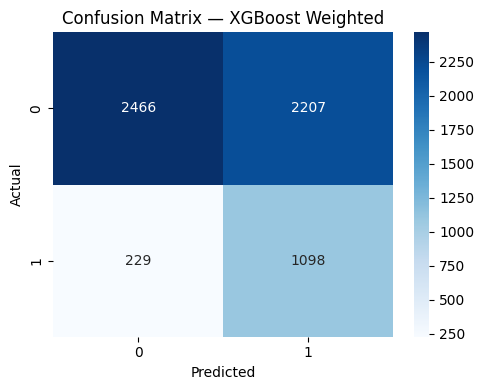

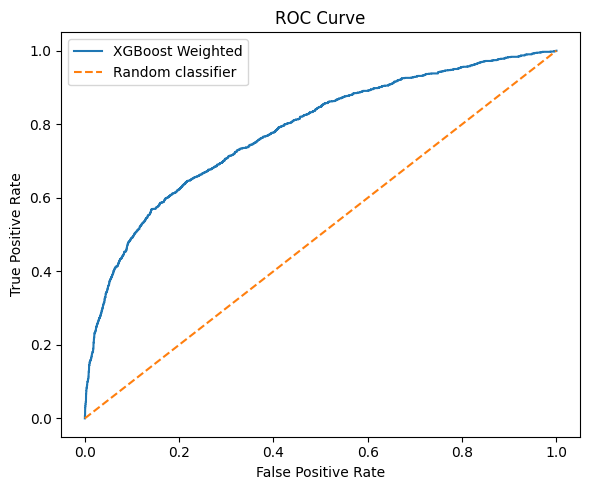

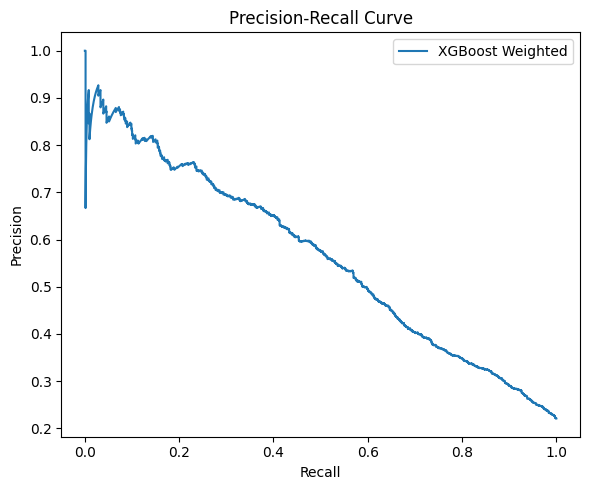

In [24]:
# ============================================================
# Confusion matrix, ROC curve, and Precision-Recall curve
# ============================================================
best_test_pred = (best_test_proba >= best_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, best_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_best_model_confusion_matrix.png", dpi=300)
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, best_test_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_roc_curve_best_model.png", dpi=300)
plt.show()

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, best_test_proba)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"{best_model_name}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_precision_recall_curve_best_model.png", dpi=300)
plt.show()

Top features increasing predicted default risk:


,feature,coefficient,odds_ratio
24,months_2plus_late,0.891614,2.439064
35,pay_amt_std,0.854532,2.350273
44,any_2plus_delay_flag,0.409030,1.505357
48,EDUCATION_2,0.237853,1.268523
42,zero_payment_months,0.208304,1.231588
47,EDUCATION_1,0.182245,1.199908
38,avg_utilisation,0.175419,1.191746
10,BILL_AMT3,0.170204,1.185546
60,LIMIT_BAND_low_limit,0.146931,1.158274
49,EDUCATION_3,0.140640,1.151010


Top features decreasing predicted default risk:


,feature,coefficient,odds_ratio
50,EDUCATION_4,-0.713467,0.489942
34,max_pay_amt,-0.493866,0.610263
29,max_bill_amt,-0.390092,0.676994
23,months_late,-0.321465,0.725086
37,recent_utilisation,-0.225169,0.798381
15,PAY_AMT2,-0.159756,0.852352
52,MARRIAGE_2,-0.156828,0.854851
54,AGE_BAND_26-35,-0.149814,0.860868
61,LIMIT_BAND_mid_high_limit,-0.142905,0.866837
59,LIMIT_BAND_high_limit,-0.140871,0.868601


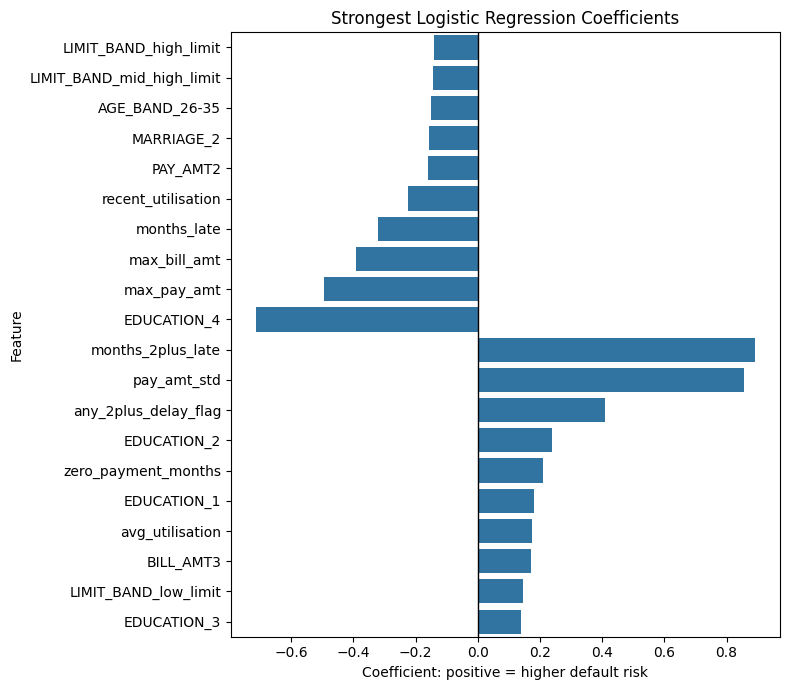

In [25]:
# ============================================================
# Logistic Regression coefficient explanation
# ============================================================
# This directly addresses the supervisor feedback:
# Logistic Regression is explainable, so we inspect which features have the strongest positive/negative weights.

log_model_name = "Logistic Regression Balanced"
log_pipe = fitted_models[log_model_name]

feature_names = get_feature_names_from_pipeline(log_pipe)
coefs = log_pipe.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("coefficient", ascending=False)

print("Top features increasing predicted default risk:")
display(coef_df.head(15))

print("Top features decreasing predicted default risk:")
display(coef_df.tail(15).sort_values("coefficient"))

coef_df.to_csv(f"{TABLE_DIR}/logistic_regression_coefficients.csv", index=False)

# Plot strongest coefficients
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)
plot_coef = pd.concat([top_negative, top_positive])

plt.figure(figsize=(8, 7))
sns.barplot(data=plot_coef, x="coefficient", y="feature")
plt.axvline(0, color="black", linewidth=1)
plt.title("Strongest Logistic Regression Coefficients")
plt.xlabel("Coefficient: positive = higher default risk")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_logistic_regression_coefficients.png", dpi=300)
plt.show()

Top feature importances for XGBoost Weighted:


,feature,importance
21,max_pay_delay,0.305802
43,high_utilisation_flag,0.073594
23,months_late,0.069048
24,months_2plus_late,0.065434
2,PAY_0,0.057960
25,recent_delay,0.041853
60,LIMIT_BAND_low_limit,0.026770
29,max_bill_amt,0.013394
42,zero_payment_months,0.011040
39,max_utilisation,0.010839


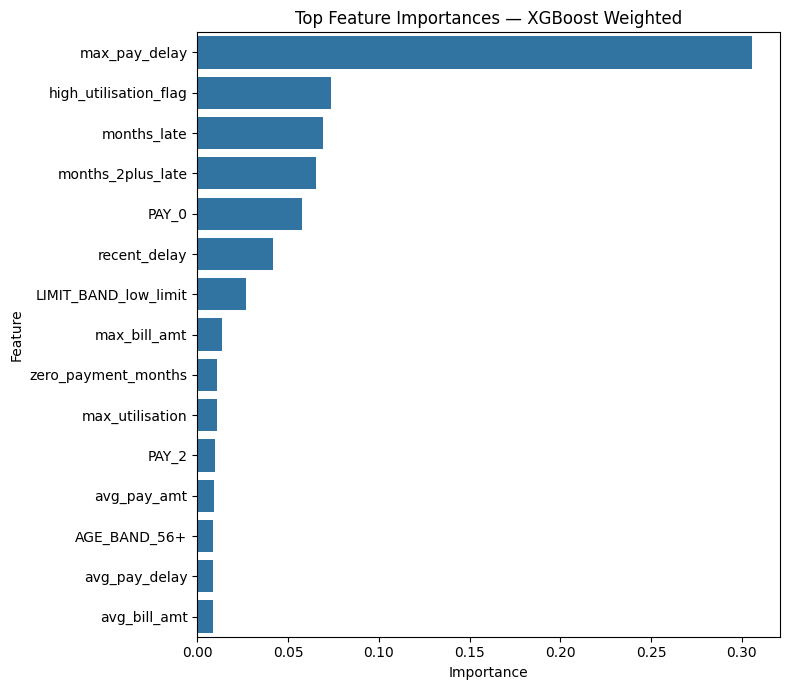

In [26]:
# ============================================================
# Tree model feature importance
# ============================================================
# For XGBoost models, feature_importances_ gives model-based importance.

if hasattr(best_model.named_steps["clf"], "feature_importances_"):
    feature_names = get_feature_names_from_pipeline(best_model)
    importances = best_model.named_steps["clf"].feature_importances_

    tree_imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"Top feature importances for {best_model_name}:")
    display(tree_imp_df.head(20))

    tree_imp_df.to_csv(f"{TABLE_DIR}/best_tree_model_feature_importance.csv", index=False)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=tree_imp_df.head(15), x="importance", y="feature")
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/09_best_tree_feature_importance.png", dpi=300)
    plt.show()
else:
    print("Best model does not have feature_importances_.")

Running permutation importance. This may take a few minutes...


,feature,importance_mean,importance_std
5,PAY_0,0.073311,0.007581
24,max_pay_delay,0.064998,0.005217
34,bill_trend_recent_minus_old,0.012201,0.003541
43,avg_payment_to_bill_ratio,0.007618,0.005137
11,BILL_AMT1,0.006967,0.003518
27,months_2plus_late,0.004659,0.002170
2,EDUCATION,0.003956,0.000475
35,avg_pay_amt,0.003672,0.001078
18,PAY_AMT2,0.003622,0.000471
15,BILL_AMT5,0.003339,0.001228


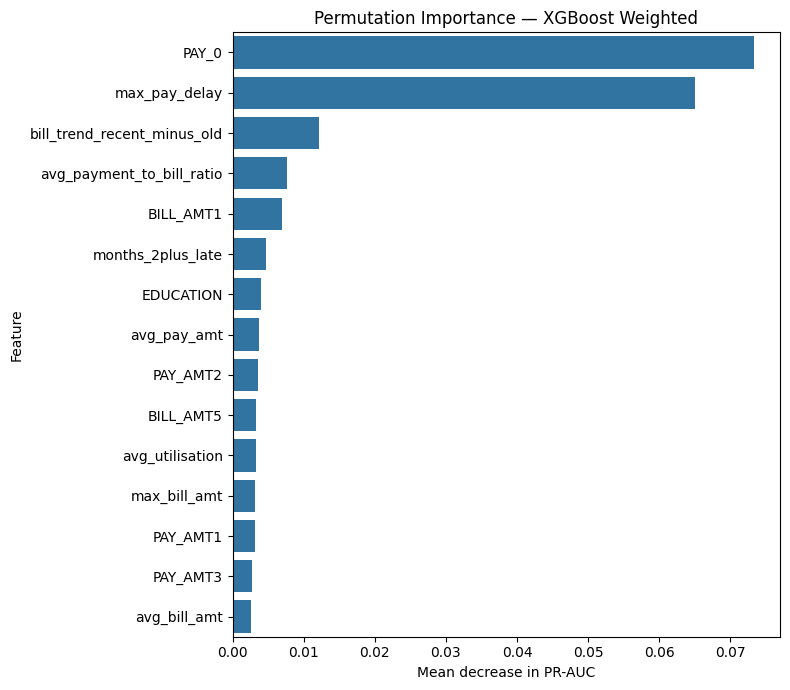

In [27]:
# ============================================================
# Permutation importance on raw/engineered features
# ============================================================
# This is useful for the report because it ranks original and engineered features directly.

print("Running permutation importance. This may take a few minutes...")

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5 if FAST_MODE else 10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))
perm_df.to_csv(f"{TABLE_DIR}/permutation_importance_raw_features.csv", index=False)

plt.figure(figsize=(8, 7))
sns.barplot(data=perm_df.head(15), x="importance_mean", y="feature")
plt.title(f"Permutation Importance — {best_model_name}")
plt.xlabel("Mean decrease in PR-AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_permutation_importance.png", dpi=300)
plt.show()

In [28]:
# ============================================================
# Error analysis: false negatives and false positives
# ============================================================
# False negatives are dangerous in credit risk:
# actual default = 1, predicted no default = 0.

error_df = X_test.copy()
error_df["actual_default"] = y_test.values
error_df["predicted_default"] = best_test_pred
error_df["predicted_probability"] = best_test_proba

false_negatives = error_df[(error_df["actual_default"] == 1) & (error_df["predicted_default"] == 0)]
false_positives = error_df[(error_df["actual_default"] == 0) & (error_df["predicted_default"] == 1)]

print("False negatives:", false_negatives.shape[0])
print("False positives:", false_positives.shape[0])

print("\nFalse negative profile:")
display(false_negatives[[
    "predicted_probability", "LIMIT_BAL", "AGE", "PAY_0", "avg_pay_delay",
    "months_late", "months_2plus_late", "recent_utilisation",
    "avg_payment_to_bill_ratio", "zero_payment_months"
]].describe())

print("\nFalse positive profile:")
display(false_positives[[
    "predicted_probability", "LIMIT_BAL", "AGE", "PAY_0", "avg_pay_delay",
    "months_late", "months_2plus_late", "recent_utilisation",
    "avg_payment_to_bill_ratio", "zero_payment_months"
]].describe())

false_negatives.to_csv(f"{TABLE_DIR}/false_negatives.csv", index=False)
false_positives.to_csv(f"{TABLE_DIR}/false_positives.csv", index=False)

False negatives: 229
False positives: 2207

False negative profile:


,predicted_probability,LIMIT_BAL,AGE,PAY_0,avg_pay_delay,months_late,months_2plus_late,recent_utilisation,avg_payment_to_bill_ratio,zero_payment_months
count,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000,229.000000
mean,0.222381,198646.288210,36.144105,-0.432314,-0.441776,0.078603,0.052402,0.404456,0.664350,0.580786
std,0.077808,128521.968041,9.180511,0.743984,0.658766,0.300476,0.242168,0.413764,0.738315,1.227884
min,0.023860,10000.000000,22.000000,-2.000000,-2.000000,0.000000,0.000000,-0.004686,0.000000,0.000000
25%,0.157323,90000.000000,29.000000,-1.000000,-0.666667,0.000000,0.000000,0.021445,0.044739,0.000000
50%,0.233601,170000.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.267380,0.326050,0.000000
75%,0.292477,280000.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.788452,1.044596,0.000000
max,0.329380,520000.000000,70.000000,1.000000,0.666667,2.000000,2.000000,2.069699,3.373999,6.000000



False positive profile:


,predicted_probability,LIMIT_BAL,AGE,PAY_0,avg_pay_delay,months_late,months_2plus_late,recent_utilisation,avg_payment_to_bill_ratio,zero_payment_months
count,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000
mean,0.520669,122596.284549,35.461260,0.037608,-0.161683,1.022202,0.826461,0.479932,0.509317,1.643407
std,0.160112,104906.432622,9.611219,1.083520,0.983085,1.502176,1.391356,0.449471,0.671425,1.855423
min,0.330075,10000.000000,21.000000,-2.000000,-2.000000,0.000000,0.000000,-0.199980,0.000000,0.000000
25%,0.393831,50000.000000,27.000000,-1.000000,-0.833333,0.000000,0.000000,0.008202,0.039246,0.000000
50%,0.472227,80000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.443978,0.079744,1.000000
75%,0.613780,180000.000000,42.000000,1.000000,0.333333,1.000000,1.000000,0.938359,0.935424,3.000000
max,0.963143,710000.000000,72.000000,6.000000,5.333333,6.000000,6.000000,3.318823,3.098200,6.000000


In [29]:
# ============================================================
# Subgroup / ethical fairness check
# ============================================================
# This is not full legal fairness auditing, but it gives useful evidence for the ethics section.

def subgroup_report(data, y_true, y_pred, y_proba, group_col):
    rows = []
    temp = data.copy()
    temp["actual"] = y_true.values
    temp["pred"] = y_pred
    temp["proba"] = y_proba

    for group_value, group_data in temp.groupby(group_col):
        if group_data.shape[0] < 50:
            continue

        yt = group_data["actual"]
        yp = group_data["pred"]
        yp_prob = group_data["proba"]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        rows.append({
            "group_column": group_col,
            "group_value": group_value,
            "n": group_data.shape[0],
            "actual_default_rate": yt.mean(),
            "predicted_default_rate": yp.mean(),
            "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "f1": f1_score(yt, yp, zero_division=0),
            "roc_auc": roc_auc_score(yt, yp_prob) if yt.nunique() == 2 else np.nan,
            "false_negative_count": fn,
            "false_positive_count": fp
        })

    return pd.DataFrame(rows)

fairness_reports = []
for group_col in ["SEX", "EDUCATION", "MARRIAGE", "AGE_BAND", "LIMIT_BAND"]:
    fairness_reports.append(subgroup_report(X_test, y_test, best_test_pred, best_test_proba, group_col))

fairness_df = pd.concat(fairness_reports, ignore_index=True)
display(fairness_df)

fairness_df.to_csv(f"{TABLE_DIR}/subgroup_fairness_check.csv", index=False)

,group_column,group_value,n,actual_default_rate,predicted_default_rate,accuracy,precision,recall,f1,roc_auc,false_negative_count,false_positive_count
0,SEX,1,2402,0.233555,0.574105,0.585346,0.342277,0.841355,0.486598,0.774793,89,907
1,SEX,2,3598,0.212896,0.535297,0.599778,0.325026,0.817232,0.465082,0.784000,140,1300
2,EDUCATION,1,2130,0.190141,0.455399,0.657746,0.332990,0.797531,0.469818,0.793199,82,647
3,EDUCATION,2,2774,0.236482,0.609589,0.559120,0.332348,0.856707,0.478909,0.781176,94,1129
4,EDUCATION,3,1014,0.257396,0.624260,0.534517,0.333333,0.808429,0.472036,0.738476,50,422
5,EDUCATION,4,82,0.060976,0.134146,0.853659,0.181818,0.400000,0.250000,0.633766,3,9
6,MARRIAGE,1,2767,0.241417,0.556198,0.606433,0.363223,0.836826,0.506570,0.781901,109,980
7,MARRIAGE,2,3158,0.204877,0.543699,0.586447,0.308096,0.817620,0.447547,0.781598,118,1188
8,MARRIAGE,3,75,0.160000,0.653333,0.453333,0.204082,0.833333,0.327869,0.675926,2,39
9,AGE_BAND,26-35,2492,0.196629,0.503612,0.617576,0.315538,0.808163,0.453868,0.785737,94,859


In [30]:
# ============================================================
# final summary text
# ============================================================
best_metrics = evaluate_predictions(y_test, best_test_proba, best_threshold)

summary_text = f"""
FINAL PROJECT MODEL SUMMARY

Best model selected using validation performance:
{best_model_name}

Final test-set results using tuned threshold {best_threshold:.2f}:
Accuracy: {best_metrics['accuracy']:.4f}
Balanced accuracy: {best_metrics['balanced_accuracy']:.4f}
Precision: {best_metrics['precision']:.4f}
Recall: {best_metrics['recall']:.4f}
F1-score: {best_metrics['f1']:.4f}
F2-score: {best_metrics['f2']:.4f}
ROC-AUC: {best_metrics['roc_auc']:.4f}
PR-AUC: {best_metrics['pr_auc']:.4f}

Confusion matrix:
True negatives: {best_metrics['tn']}
False positives: {best_metrics['fp']}
False negatives: {best_metrics['fn']}
True positives: {best_metrics['tp']}

Interpretation guide:
- Accuracy alone is not enough because the dataset is imbalanced.
- Recall is important because false negatives mean customers who actually default are missed.
- PR-AUC is useful because the positive default class is the minority class.
- Logistic Regression coefficients explain the direction and strength of feature effects.
- Permutation importance and tree feature importance identify the most influential behavioural predictors.
"""

print(summary_text)

with open(f"{OUTPUT_DIR}/final_summary_for_report.txt", "w") as f:
    f.write(summary_text)


FINAL PROJECT MODEL SUMMARY

Best model selected using validation performance:
XGBoost Weighted

Final test-set results using tuned threshold 0.33:
Accuracy: 0.5940
Balanced accuracy: 0.6776
Precision: 0.3322
Recall: 0.8274
F1-score: 0.4741
F2-score: 0.6374
ROC-AUC: 0.7807
PR-AUC: 0.5621

Confusion matrix:
True negatives: 2466
False positives: 2207
False negatives: 229
True positives: 1098

Interpretation guide:
- Accuracy alone is not enough because the dataset is imbalanced.
- Recall is important because false negatives mean customers who actually default are missed.
- PR-AUC is useful because the positive default class is the minority class.
- Logistic Regression coefficients explain the direction and strength of feature effects.
- Permutation importance and tree feature importance identify the most influential behavioural predictors.



In [31]:
# ============================================================
# RISK GROUP CLASSIFICATION: HIGH / MEDIUM / LOW
# ============================================================

# Predict default probability for test customers
risk_probabilities = best_model.predict_proba(X_test)[:, 1]

# Create results table
risk_customers = X_test.copy()
risk_customers["actual_default"] = y_test.values
risk_customers["default_probability"] = risk_probabilities

# Risk category rule
def assign_risk_group(prob):
    if prob >= 0.60:
        return "High Risk"
    elif prob >= 0.30:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_customers["risk_group"] = risk_customers["default_probability"].apply(assign_risk_group)

# Sort from highest risk to lowest risk
risk_customers = risk_customers.sort_values("default_probability", ascending=False)

# Show number of customers in each risk group
print("Number of customers in each risk group:")
display(risk_customers["risk_group"].value_counts())

# Show high-risk customers
print("High Risk Customers")
display(
    risk_customers[risk_customers["risk_group"] == "High Risk"][
        [
            "default_probability",
            "risk_group",
            "actual_default",
            "LIMIT_BAL",
            "AGE",
            "PAY_0",
            "avg_pay_delay",
            "months_late",
            "months_2plus_late",
            "recent_utilisation",
            "avg_payment_to_bill_ratio",
            "zero_payment_months"
        ]
    ].head(20)
)

# Show medium-risk customers
print("Medium Risk Customers")
display(
    risk_customers[risk_customers["risk_group"] == "Medium Risk"][
        [
            "default_probability",
            "risk_group",
            "actual_default",
            "LIMIT_BAL",
            "AGE",
            "PAY_0",
            "avg_pay_delay",
            "months_late",
            "months_2plus_late",
            "recent_utilisation",
            "avg_payment_to_bill_ratio",
            "zero_payment_months"
        ]
    ].head(20)
)

# Show low-risk customers
print("Low Risk Customers")
display(
    risk_customers[risk_customers["risk_group"] == "Low Risk"][
        [
            "default_probability",
            "risk_group",
            "actual_default",
            "LIMIT_BAL",
            "AGE",
            "PAY_0",
            "avg_pay_delay",
            "months_late",
            "months_2plus_late",
            "recent_utilisation",
            "avg_payment_to_bill_ratio",
            "zero_payment_months"
        ]
    ].head(20)
)

# Save full customer risk table
risk_customers.to_csv(f"{TABLE_DIR}/customer_risk_groups.csv", index=False)

print("Saved file:")
print(f"{TABLE_DIR}/customer_risk_groups.csv")

Number of customers in each risk group:


,count
risk_group,
Low Risk,2378
Medium Risk,2323
High Risk,1299


High Risk Customers


,default_probability,risk_group,actual_default,LIMIT_BAL,AGE,PAY_0,avg_pay_delay,months_late,months_2plus_late,recent_utilisation,avg_payment_to_bill_ratio,zero_payment_months
27536,0.965263,High Risk,1,250000,51,3,2.166667,6,6,0.009948,0.000000,6
28054,0.964895,High Risk,1,20000,32,3,4.666667,6,6,0.119994,0.000000,6
28747,0.963143,High Risk,0,50000,28,3,4.666667,6,6,0.047999,0.000000,6
1956,0.962431,High Risk,1,220000,42,2,2.000000,6,6,0.011364,0.000000,6
14973,0.961433,High Risk,1,30000,55,2,5.333333,6,6,0.079831,0.000000,6
20721,0.961401,High Risk,1,20000,37,3,4.666667,6,6,0.119994,0.000000,6
29770,0.961025,High Risk,1,20000,31,3,4.666667,6,6,0.119994,0.000000,6
13966,0.959248,High Risk,1,40000,55,2,5.333333,6,6,0.059999,0.000000,6
24397,0.959064,High Risk,1,20000,36,3,2.666667,6,6,0.052497,0.000000,6
18094,0.958559,High Risk,1,20000,42,3,2.666667,6,6,0.052497,0.000000,6


Medium Risk Customers


,default_probability,risk_group,actual_default,LIMIT_BAL,AGE,PAY_0,avg_pay_delay,months_late,months_2plus_late,recent_utilisation,avg_payment_to_bill_ratio,zero_payment_months
13260,0.599710,Medium Risk,0,10000,26,0,0.000000,0,0,0.634537,0.079654,0
13282,0.599544,Medium Risk,0,110000,25,1,0.833333,3,2,0.549913,0.038811,0
23575,0.599496,Medium Risk,0,210000,38,-2,-2.000000,0,0,-0.000386,0.000000,6
21286,0.599429,Medium Risk,0,110000,57,-1,-1.000000,0,0,0.003545,0.997442,0
25490,0.599197,Medium Risk,0,20000,22,1,0.500000,2,1,0.938003,0.046649,1
5253,0.598477,Medium Risk,0,200000,63,-1,-1.000000,0,0,0.001580,0.996845,0
653,0.598368,Medium Risk,1,450000,42,1,-1.166667,1,0,-0.000444,0.999171,4
2306,0.598012,Medium Risk,0,30000,26,0,0.000000,1,1,0.351322,0.852407,3
12386,0.597978,Medium Risk,1,10000,39,1,0.000000,2,1,0.000000,0.852434,3
7704,0.597894,Medium Risk,0,200000,38,0,1.000000,3,3,0.902425,0.038700,2


Low Risk Customers


,default_probability,risk_group,actual_default,LIMIT_BAL,AGE,PAY_0,avg_pay_delay,months_late,months_2plus_late,recent_utilisation,avg_payment_to_bill_ratio,zero_payment_months
22007,0.299912,Low Risk,0,80000,24,0,-0.333333,0,0,0.529706,0.956841,0
17759,0.299878,Low Risk,0,180000,52,0,0.000000,0,0,0.961467,0.036033,0
255,0.299817,Low Risk,0,50000,25,0,0.000000,0,0,0.553969,0.039613,0
22632,0.299699,Low Risk,0,230000,38,1,-1.000000,1,0,0.003600,2.216356,0
20095,0.299657,Low Risk,0,140000,42,0,0.000000,0,0,1.114721,0.037158,0
2073,0.299615,Low Risk,0,250000,50,-2,-1.500000,0,0,0.001560,1.567598,0
2840,0.299469,Low Risk,0,210000,32,-1,-0.500000,0,0,0.009295,1.230718,0
1402,0.299423,Low Risk,1,70000,44,0,0.000000,0,0,0.060299,0.234220,0
25745,0.299111,Low Risk,0,240000,38,0,0.666667,2,2,0.137420,0.149912,1
9356,0.298978,Low Risk,1,130000,29,-2,-2.000000,0,0,-0.001538,0.999171,4


Saved file:
/content/credit_default_outputs/tables/customer_risk_groups.csv
